Ep   500 | AvgR=-402.57 | Succ=100.0% | ε=0.050 | EpTime=0.034s
Ep  1000 | AvgR=-426.25 | Succ=100.0% | ε=0.050 | EpTime=0.026s
Ep  1500 | AvgR=-462.19 | Succ=100.0% | ε=0.050 | EpTime=0.035s
Ep  2000 | AvgR=-449.35 | Succ=100.0% | ε=0.050 | EpTime=0.033s
Ep  2500 | AvgR=-461.19 | Succ=100.0% | ε=0.050 | EpTime=0.030s
Ep  3000 | AvgR=-474.55 | Succ=100.0% | ε=0.050 | EpTime=0.029s
Ep  3500 | AvgR=-467.61 | Succ=100.0% | ε=0.050 | EpTime=0.034s
Ep  4000 | AvgR=-453.33 | Succ=100.0% | ε=0.050 | EpTime=0.030s
Ep  4500 | AvgR=-465.85 | Succ=100.0% | ε=0.050 | EpTime=0.038s
Ep  5000 | AvgR=-459.87 | Succ=100.0% | ε=0.050 | EpTime=0.035s
Ep  5500 | AvgR=-448.23 | Succ=100.0% | ε=0.050 | EpTime=0.032s
Ep  6000 | AvgR=-458.55 | Succ=100.0% | ε=0.050 | EpTime=0.029s
Ep  6500 | AvgR=-444.13 | Succ=100.0% | ε=0.050 | EpTime=0.036s
Ep  7000 | AvgR=-423.19 | Succ=100.0% | ε=0.050 | EpTime=0.031s
Ep  7500 | AvgR=-434.03 | Succ=100.0% | ε=0.050 | EpTime=0.030s
Ep  8000 | AvgR=-425.63 | Succ=100.0% | 

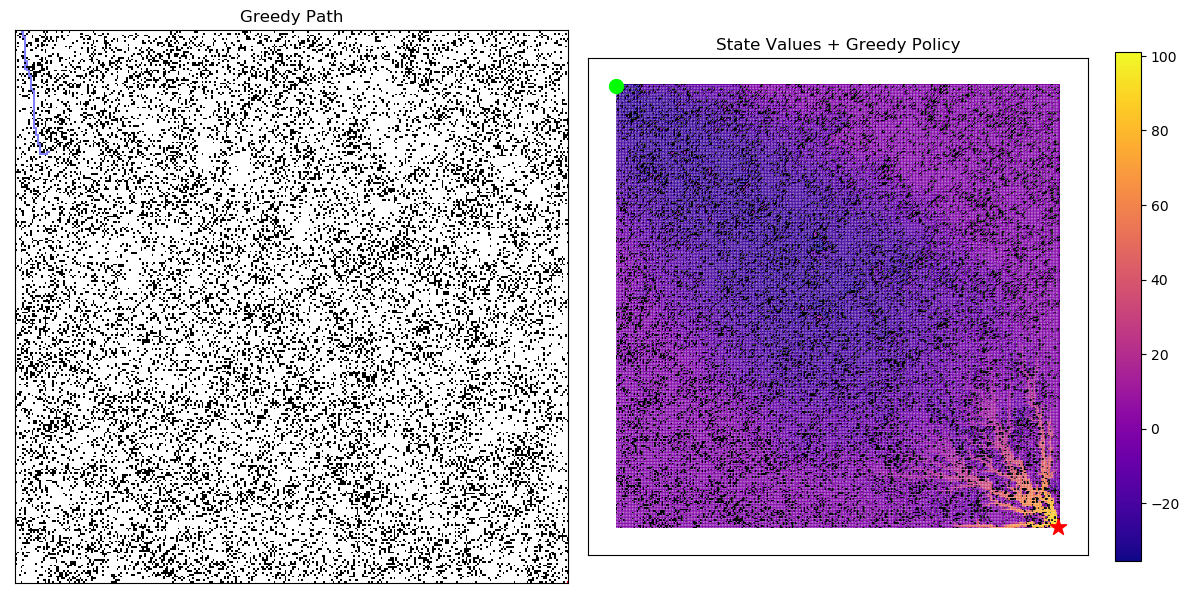

In [ ]:
#!/usr/bin/env python3
"""
Enhanced Q-learning Grid-World (Python 3.8+)
-------------------------------------------
• Adaptive ε-greedy, reward shaping, 4/8-direction moves
• Clustered/random obstacles (seeded)
• Large grids (tested 300×300)
• Combined visual: greedy path & value-map with arrows
"""

import math, time
from collections import deque
from typing import List, Tuple, Optional

import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------------------
# GridWorld environment
# ---------------------------------------------------------------------
class GridWorld:
    def __init__(
        self,
        width: int,
        height: int,
        obstacle_density: float = 0.2,
        obstacle_mode: str = "cluster",            # 'random' | 'cluster'
        seed: Optional[int] = None,
        cluster_size: int = 5,
        start: Optional[Tuple[int, int]] = None,
        goal: Optional[Tuple[int, int]] = None,
        allow_diagonal: bool = False,
        diagonal_cost: Optional[float] = None,
        reward_goal: float = 100.0,
        reward_obstacle: float = -10.0,
        reward_step: float = -1.0,
        shaping: Optional[str] = "euclidean",      # None | 'manhattan' | 'euclidean'
    ):
        self.width, self.height = width, height
        self.obstacle_density = obstacle_density
        self.obstacle_mode = obstacle_mode
        self.cluster_size = cluster_size
        self.rng = np.random.RandomState(seed)
        self.reward_goal = reward_goal
        self.reward_obstacle = reward_obstacle
        self.reward_step = reward_step
        self.shaping = shaping
        self.allow_diag = allow_diagonal
        self.diag_cost = (
            diagonal_cost if diagonal_cost is not None
            else (math.sqrt(2) if allow_diagonal else 1.0)
        )

        # Build grid --------------------------------------------------
        self.grid = np.zeros((height, width), dtype=np.int8)  # 0 free, 1 obstacle
        self._populate_obstacles()
        self.start = tuple(start) if start else (0, 0)
        self.goal = tuple(goal) if goal else (height - 1, width - 1)
        self.grid[self.start] = 0
        self.grid[self.goal] = 0

        # Action set --------------------------------------------------
        if allow_diagonal:
            self.actions: List[Tuple[int, int]] = [
                (-1, 0), (1, 0), (0, -1), (0, 1),
                (-1, -1), (-1, 1), (1, -1), (1, 1)
            ]
        else:
            self.actions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        self.num_actions = len(self.actions)
        self.agent_pos: Optional[Tuple[int, int]] = None

    # -----------------------------------------------------------------
    def _populate_obstacles(self) -> None:
        total = self.width * self.height
        n_obs = int(total * self.obstacle_density)
        if n_obs == 0:
            return
        if self.obstacle_mode == "random":
            idx = self.rng.choice(total, size=n_obs, replace=False)
            self.grid.flat[idx] = 1
            return
        # cluster mode
        placed = 0
        while placed < n_obs:
            center_r = self.rng.randint(0, self.height)
            center_c = self.rng.randint(0, self.width)
            for _ in range(self.cluster_size):
                if placed >= n_obs:
                    break
                dr = self.rng.randint(-self.cluster_size, self.cluster_size + 1)
                dc = self.rng.randint(-self.cluster_size, self.cluster_size + 1)
                r, c = center_r + dr, center_c + dc
                if 0 <= r < self.height and 0 <= c < self.width and self.grid[r, c] == 0:
                    self.grid[r, c] = 1
                    placed += 1

    # -----------------------------------------------------------------
    def reset(self) -> Tuple[int, int]:
        self.agent_pos = self.start
        return self.agent_pos

    def step(self, action: int) -> Tuple[Tuple[int, int], float, bool]:
        r, c = self.agent_pos
        dr, dc = self.actions[action]
        nr, nc = r + dr, c + dc

        # invalid move (wall or obstacle) -----------------------------
        if not (0 <= nr < self.height and 0 <= nc < self.width) or self.grid[nr, nc] == 1:
            next_state = (r, c)
            reward, done = self.reward_obstacle, False
        else:
            next_state = (nr, nc)
            self.agent_pos = next_state
            if next_state == self.goal:
                reward, done = self.reward_goal, True
            else:
                step_pen = (
                    -abs(self.diag_cost)
                    if self.allow_diag and dr and dc and self.reward_step < 0
                    else self.reward_step
                )
                reward, done = step_pen, False

        # potential-based shaping ------------------------------------
        if self.shaping in ("manhattan", "euclidean"):
            def dist(s):
                if self.shaping == "manhattan":
                    return abs(s[0] - self.goal[0]) + abs(s[1] - self.goal[1])
                return math.hypot(s[0] - self.goal[0], s[1] - self.goal[1])
            reward += dist((r, c)) - dist(next_state)

        return next_state, reward, done


# ---------------------------------------------------------------------
# Q-learning agent
# ---------------------------------------------------------------------
class QLearningAgent:
    def __init__(
        self,
        env: GridWorld,
        alpha: float = 0.1,
        gamma: float = 0.99,
        epsilon: float = 1.0,
        min_epsilon: float = 0.05,
        epsilon_decay: float = 0.9,
        schedule: str = "adaptive",           # 'adaptive' | 'exponential'
    ):
        self.env = env
        self.alpha, self.gamma = alpha, gamma
        self.epsilon, self.min_eps, self.decay = epsilon, min_epsilon, epsilon_decay
        self.schedule = schedule
        self.Q = np.zeros((env.height, env.width, env.num_actions))

    def choose_action(self, state: Tuple[int, int]) -> int:
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.env.num_actions)
        r, c = state
        q = self.Q[r, c]
        return int(np.random.choice(np.flatnonzero(q == q.max())))

    def update(self, s, a, r, s2, done) -> None:
        r0, c0 = s
        r1, c1 = s2
        target = r if done else r + self.gamma * self.Q[r1, c1].max()
        self.Q[r0, c0, a] += self.alpha * (target - self.Q[r0, c0, a])

    def decay_epsilon(self, success_rate: float, threshold: float = 0.8) -> None:
        if self.schedule == "adaptive":
            if success_rate >= threshold and self.epsilon > self.min_eps:
                self.epsilon = max(self.min_eps, self.epsilon * self.decay)
        else:
            self.epsilon = max(self.min_eps, self.epsilon * self.decay)


# ---------------------------------------------------------------------
# Training & helpers
# ---------------------------------------------------------------------
def train(
    env,
    agent,
    episodes: int = 5000,
    window: int = 100,
    print_every: int = 100,
    threshold: float = 0.8,
):
    rewards, successes, ep_durations = deque(maxlen=window), deque(maxlen=window), []
    t_start = time.perf_counter()

    for ep in range(1, episodes + 1):
        ep_begin = time.perf_counter()
        s, tot, done = env.reset(), 0.0, False

        while not done:
            a = agent.choose_action(s)
            s2, r, done = env.step(a)
            agent.update(s, a, r, s2, done)
            s, tot = s2, tot + r

        # timing ------------------------------------------------------
        ep_time = time.perf_counter() - ep_begin
        ep_durations.append(ep_time)

        rewards.append(tot)
        successes.append(1 if done else 0)
        agent.decay_epsilon(float(np.mean(successes)), threshold)

        if ep % print_every == 0:
            print(
                f"Ep {ep:5d} | AvgR={np.mean(rewards):7.2f} | "
                f"Succ={np.mean(successes)*100:5.1f}% | "
                f"ε={agent.epsilon:.3f} | "
                f"EpTime={ep_time:.3f}s"
            )

    total_time = time.perf_counter() - t_start
    print(f"\nTraining finished in {total_time:.2f} seconds "
          f"({total_time/episodes:.3f} s/episode on average).")

    return list(ep_durations) 


def greedy_path(env: GridWorld, agent: QLearningAgent, limit: int = 1000):
    backup = agent.epsilon
    agent.epsilon = 0.0
    s, path = env.reset(), [env.start]
    for _ in range(limit):
        if s == env.goal:
            break
        a = agent.choose_action(s)
        s, _, done = env.step(a)
        path.append(s)
        if done:
            break
    agent.epsilon = backup
    return path


# ---------------------------------------------------------------------
# Combined visualisation
# ---------------------------------------------------------------------
def path_image(env: GridWorld, path: List[Tuple[int, int]]):
    img = np.ones((env.height, env.width, 3))
    img[env.grid == 1] = (0, 0, 0)
    img[env.start] = (0, 1, 0)
    img[env.goal] = (1, 0, 0)
    for r, c in path:
        if (r, c) not in (env.start, env.goal) and env.grid[r, c] == 0:
            img[r, c] = (0.5, 0.5, 1)
    return img


def draw_q_heatmap(ax, env: GridWorld, agent: QLearningAgent):
    V = agent.Q.max(axis=2)
    best = agent.Q.argmax(axis=2)
    Y, X = np.mgrid[0 : env.height, 0 : env.width]
    U, Vv = np.zeros_like(V), np.zeros_like(V)
    for r in range(env.height):
        for c in range(env.width):
            if env.grid[r, c] == 1:
                continue
            dr, dc = env.actions[best[r, c]]
            U[r, c], Vv[r, c] = dc, -dr

    cmap_val = "turbo" if "turbo" in plt.colormaps() else "plasma"
    V_mask = np.ma.masked_where(env.grid == 1, V)
    im = ax.imshow(V_mask, cmap=cmap_val, origin="upper")
    plt.colorbar(im, ax=ax, fraction=0.046)

    ax.imshow(
        np.ma.masked_where(env.grid == 0, env.grid),
        cmap="gray_r",              # reversed gray => obstacle black
        origin="upper",
        vmin=0,
        vmax=1,
        interpolation="nearest",
        alpha=1,
    )

    free = env.grid.flatten() == 0
    ax.quiver(
        X.flatten()[free],
        Y.flatten()[free],
        U.flatten()[free],
        Vv.flatten()[free],
        color="white",
        scale=env.width * 1.5,
        pivot="mid",
        headwidth=4,
        headlength=5,
        width=0.002,
    )

    ax.scatter(env.start[1], env.start[0], marker="o", c="lime", s=100, zorder=5)
    ax.scatter(env.goal[1], env.goal[0], marker="*", c="red", s=150, zorder=5)
    ax.set_title("State Values + Greedy Policy")
    ax.set_xticks([]), ax.set_yticks([])


def combined_vis(
    env: GridWorld,
    agent: QLearningAgent,
    path,
    save_path: str = "combined_vis.png",
    dpi: int = 800,
    show: bool = True,
):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # ---- Left panel: greedy path ------------------------------------------
    ax1.imshow(path_image(env, path), origin="upper")
    ax1.set_title("Greedy Path")
    ax1.set_xticks([]); ax1.set_yticks([])

    # ---- Right panel: Q-value heat-map + greedy policy arrows -------------
    draw_q_heatmap(ax2, env, agent)

    # ---- Layout, save, and optionally display ----------------------------
    plt.tight_layout()
    fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

# ---------------------------------------------------------------------
# MAIN
# ---------------------------------------------------------------------
if __name__ == "__main__":
    GRID = 300                          # try 100 or 300 if you like
    env = GridWorld(
        width=GRID,
        height=GRID,
        obstacle_density=0.22,
        obstacle_mode="cluster",
        seed=42,
        allow_diagonal=False,
        shaping="euclidean",
    )

    agent = QLearningAgent(
        env,
        alpha=0.1,
        gamma=0.99,
        epsilon=1.0,
        min_epsilon=0.05,
        epsilon_decay=0.9,
        schedule="adaptive",
    )

    durations = train(env, agent, episodes=100000, print_every=500)

    path = greedy_path(env, agent)
    combined_vis(env, agent, path)


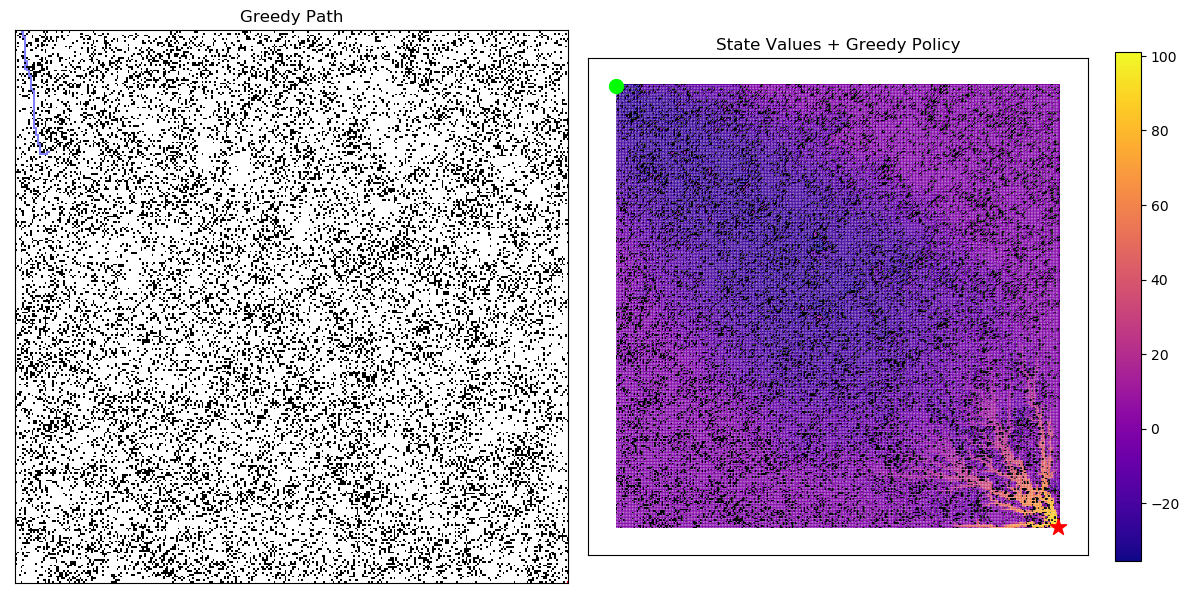

In [6]:
from pathlib import Path

def combined_vis(
    env: GridWorld,
    agent: QLearningAgent,
    path,
    save_path: str = "combined_vis.pdf",  # default is now vector PDF
    dpi: int = 800,
    show: bool = True,
):
    """
    Create the greedy-path / Q-heat-map figure and save it.

    Parameters
    ----------
    env : GridWorld
        Environment instance.
    agent : QLearningAgent
        Trained agent containing Q-table.
    path : list[tuple[int, int]]
        Greedy path cells.
    save_path : str, optional
        Output file (extension decides format: .png, .pdf, .svg, …).
    dpi : int, optional
        Dots-per-inch for raster formats (PNG, JPG). Ignored for vector files.
    show : bool, optional
        Whether to display the figure window.  Default True.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # Left panel ─ greedy path
    ax1.imshow(path_image(env, path), origin="upper")
    ax1.set_title("Greedy Path")
    ax1.set_xticks([]); ax1.set_yticks([])

    # Right panel ─ heat-map + arrows
    draw_q_heatmap(ax2, env, agent)

    plt.tight_layout()

    # Decide whether dpi matters (vector vs raster)
    ext = Path(save_path).suffix.lower()
    if ext in {".png", ".jpg", ".jpeg", ".tif", ".tiff"}:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    else:  # vector formats: .pdf, .svg, .eps …
        fig.savefig(save_path, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

combined_vis(env, agent, path)


In [8]:
if 0:
    print("This is a test")

In [9]:
class Robot:
    def __init__(self):
        self._speed = 0

    @property
    def speed(self, value):
        print(value)
        return self._speed

    # @speed.setter
    # def speed(self, value):
    #     if value < 0:
    #         raise ValueError("Speed can't be negative")
    #     self._speed = value


In [10]:
r = Robot()
# r.speed = 10       # uses the setter
print(r.speed)     # uses the getter


TypeError: speed() missing 1 required positional argument: 'value'